---
title: "The state of Young Adult (18 - 24) Unemployment in the UK"
format:
  html:
    fig-format: retina
jupyter: python3
execute: 
  enabled: true
---

### Are young people in the UK working less than previous generations? If so, what are they doing instead, and what might this mean for the future workforce?

**Executive Summary:**
*   **Are Young People working less?** Yes. Since 2004, the employment rate for 18–24 year olds has dropped significantly, while the economic inactivity rate has surged from ~25% to over ~32%.

   
*   **What are they primarily doing with that time? -> Education & Health-Related Inactivity.**


    *   The largest portion of young adults (18–24) who are not in employment are actually in full-time education. As of early 2026, **~25.5%** of the entire 18–24 demographic are economically inactive students.
  
    *   However, there is a growing, structural crisis. The NEET (Not in Education, Employment, or Training) rate has risen to **15.8%**. Crucially, the majority of these NEETs (**9.4%**) are *economically inactive* (not looking for work), largely driven by long-term mental and physical health conditions. Only **6.4%** are actively seeking employment.

*   **What will this mean for us all?** While higher education participation delays entry into the workforce (creating a short-term labor squeeze but potentially higher long-term productivity), the rising rate of inactive, unwell NEETs presents a severe economic threat. It risks long-term "wage scarring" for a generation of young adults and a shrinking tax base coupled with higher social safety net reliance for the broader UK economy.

# Data Parsing & Initialisation

This section defines the parsing utilities used throughout the notebook, then uses them **once** to load every dataset we need. Two ONS source files are used:

*   `data/A05.xls` — employment / inactivity rates, broken down by sheet (`People`, `Men`, `Women`).
*   `data/NEET.xlsx` — NEET (Not in Education, Employment or Training) rates, broken down by sheet (`People - SA`, `Men - SA`, `Women - SA`).

Rather than re-parsing these files (and re-defining the parsing functions) every time a graph needs them, each sheet is parsed exactly once into a dataframe below, and every chart later in the notebook simply reuses those dataframes.

In [1]:
import re

import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go


def extract_year(period):
    """Converts an ONS string period (e.g., 'Nov-Jan 1993') into a chronological fractional year."""
    if not isinstance(period, str):
        return None

    month_offsets = {
        'Jan': 0.0, 'Feb': 1/12, 'Mar': 2/12, 'Apr': 3/12,
        'May': 4/12, 'Jun': 5/12, 'Jul': 6/12, 'Aug': 7/12,
        'Sep': 8/12, 'Oct': 9/12, 'Nov': 10/12, 'Dec': 11/12
    }

    # 1. Prevent footnotes at the bottom of the file from being parsed
    start_month = period[:3]
    if start_month not in month_offsets:
        return None

    # 2. Extract a valid 4-digit year
    match = re.search(r'(19\d{2}|20\d{2})', period)
    if not match:
        return None

    yr = int(match.group(1))

    # 3. Fix the calendar boundary issue for Nov/Dec
    if start_month in ['Nov', 'Dec']:
        yr -= 1

    return yr + month_offsets[start_month]


def find_col(df, *keywords):
    """Returns the first column name in df containing every keyword given."""
    for c in df.columns:
        if all(k in c for k in keywords):
            return c
    raise KeyError(f"No column found matching {keywords} in columns: {list(df.columns)}")

In [2]:
def parse_a05_sheet(filepath, sheet_name):
    """Parses a sheet from the ONS A05 (employment/inactivity) dataset into a clean pandas DataFrame."""
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # Locate the start of the table
    header_start = raw.index[raw.iloc[:, 1].astype(str).str.contains("Aged 16 and over", na=False)][0]

    # Four header rows
    age_row = raw.iloc[header_start]
    measure_row = raw.iloc[header_start + 1]
    stat_row = raw.iloc[header_start + 2]
    code_row = raw.iloc[header_start + 3]

    # Data starts after the blank row
    data_start = header_start + 5
    df = raw.iloc[data_start:].reset_index(drop=True)

    # Build readable column names, forward-filling the merged age/measure header cells
    columns = []
    current_age = ""
    current_measure = ""

    for age, measure, stat, code_ in zip(age_row, measure_row, stat_row, code_row):
        if pd.notna(age):
            current_age = str(age).strip()
        if pd.notna(measure):
            current_measure = str(measure).strip()

        parts = [
            current_age,
            current_measure,
            str(stat).strip() if pd.notna(stat) else "",
            str(code_).strip() if pd.notna(code_) else "",
        ]
        columns.append("_".join(p for p in parts if p))

    df.columns = columns
    df = df.rename(columns={df.columns[0]: "Period"})
    df = df.dropna(how="all")

    # Convert numeric columns safely
    for c in df.columns[1:]:
        df[c] = df[c].astype(str).str.replace(",", "", regex=False).replace("nan", pd.NA)
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df['Year_Fraction'] = df['Period'].apply(extract_year)

    # Drop rows where the period couldn't be parsed (e.g. footnotes)
    return df.dropna(subset=['Year_Fraction']).copy()


def parse_neet_sheet(filepath, sheet_name):
    """Robustly parses a sheet from the ONS NEET dataset into a clean pandas DataFrame."""
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # Locate where the actual data starts by finding the "Levels" string in the first column
    header_start = raw.index[raw.iloc[:, 0].astype(str).str.contains("Levels", na=False)][0]

    # Headers are spread across three rows directly above the data start
    age_row = raw.iloc[header_start - 2]
    metric_row = raw.iloc[header_start - 1]
    sub_metric_row = raw.iloc[header_start]

    data_start = header_start + 3
    df = raw.iloc[data_start:].reset_index(drop=True)

    columns = []
    current_age = ""
    current_metric = ""

    # Forward-fill logic for the merged header cells
    for age, metric, sub in zip(age_row, metric_row, sub_metric_row):
        if pd.notna(age) and str(age).strip() != "":
            current_age = str(age).strip()
        if pd.notna(metric) and str(metric).strip() != "":
            current_metric = str(metric).strip()

        parts = [current_age, current_metric, str(sub).strip() if pd.notna(sub) else ""]
        columns.append("_".join(p for p in parts if p and p != 'NaN'))

    df.columns = columns
    df = df.rename(columns={df.columns[0]: "Period"})
    df = df.dropna(how="all", subset=["Period"])

    # Clean numerical columns and handle '..' missing-data markers
    for c in df.columns[1:]:
        df[c] = df[c].astype(str).str.replace(",", "", regex=False).replace("..", pd.NA).replace("nan", pd.NA)
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df['Year_Fraction'] = df['Period'].apply(extract_year)
    df = df.dropna(subset=['Year_Fraction']).copy()

    # The NEET dataset begins tracking later than A05, and the early rows for the
    # 18-24 rate are blank; drop them so charts start from real data.
    rate_col = find_col(df, "18-24", "NEET as a percentage")
    return df.dropna(subset=[rate_col]).copy()

## Load every dataset once

Each sheet is parsed a single time here. `df_people` / `df_men` / `df_women` come from the A05 workbook; `df_neet_people` / `df_neet_men` / `df_neet_women` come from the NEET workbook. Every graph below reuses these six dataframes instead of re-reading the Excel files.

In [3]:
# A05 workbook: employment & inactivity rates
df_people = parse_a05_sheet("data/A05.xls", "People")
df_men = parse_a05_sheet("data/A05.xls", "Men")
df_women = parse_a05_sheet("data/A05.xls", "Women")

# NEET workbook: seasonally-adjusted NEET rates
df_neet_people = parse_neet_sheet("data/NEET.xlsx", "People - SA")
df_neet_men = parse_neet_sheet("data/NEET.xlsx", "Men - SA")
df_neet_women = parse_neet_sheet("data/NEET.xlsx", "Women - SA")

# Some graphs

Most of the charts below are Plotly line charts that only differ in which lines they draw and how the axes are labelled. Two small helpers take care of that shared boilerplate: `line_trace` builds a single styled line, and `style_figure` applies a consistent layout (white template, unified hover, sensible defaults) to every figure.

In [4]:
def line_trace(x, y, name, color, width=2, dash=None):
    """Builds a single styled Plotly line trace."""
    return go.Scatter(x=x, y=y, mode='lines', name=name, line=dict(color=color, width=width, dash=dash))


def style_figure(fig, title, yaxis_title, xaxis_title='Year', height=550, width=None,
                  yaxis_range=None, legend=None):
    """Applies the shared layout styling used by every line chart in this notebook."""
    layout = dict(
        title=title,
        xaxis_title=xaxis_title,
        yaxis_title=yaxis_title,
        template='plotly_white',
        hovermode='x unified',
        height=height,
    )
    layout['yaxis'] = dict(range=yaxis_range) if yaxis_range else dict(autorange=True)
    if width:
        layout['width'] = width
    if legend:
        layout['legend'] = legend

    fig.update_layout(**layout)
    return fig

## Employment and inactivity, by gender

First, how do employment and inactivity rates for 18-24 year olds compare between men and women?

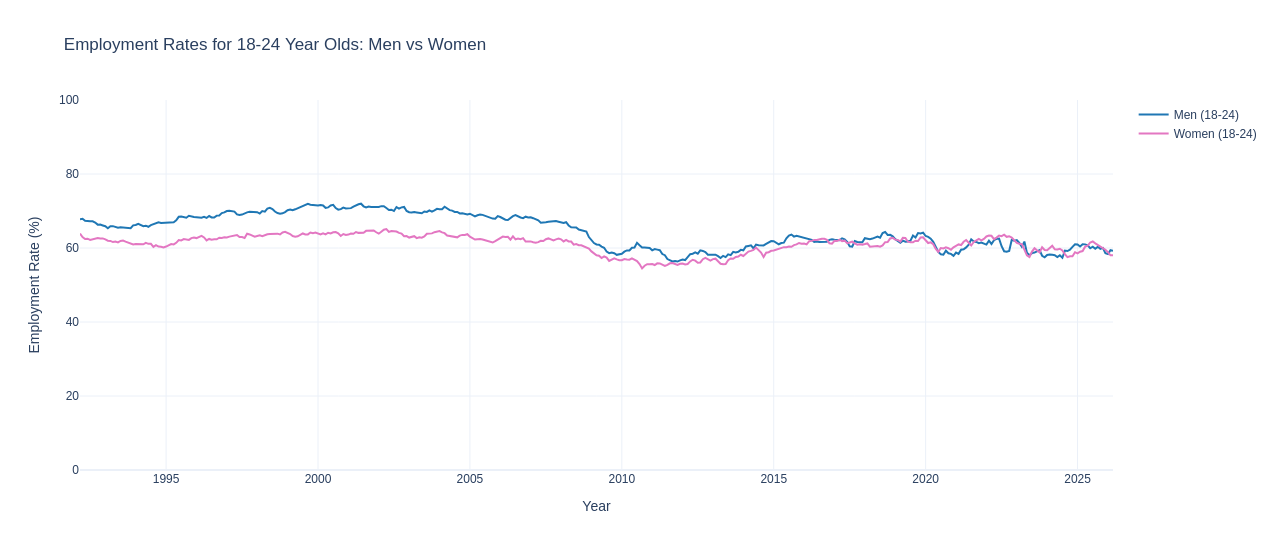

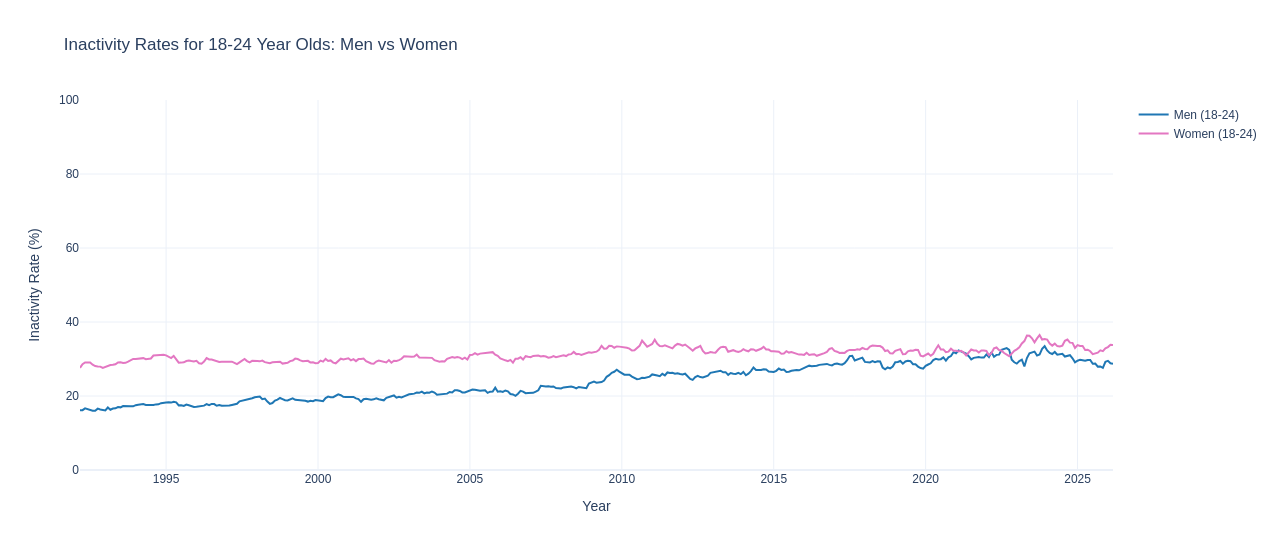

In [5]:
col_men_emp = find_col(df_men, "Aged 18-24", "Employment_rate")
col_men_inac = find_col(df_men, "Aged 18-24", "Inactivity_rate")
col_women_emp = find_col(df_women, "Aged 18-24", "Employment_rate")
col_women_inac = find_col(df_women, "Aged 18-24", "Inactivity_rate")

# Employment: Men vs Women
fig_emp = go.Figure(data=[
    line_trace(df_men['Year_Fraction'], df_men[col_men_emp], 'Men (18-24)', '#1f77b4'),
    line_trace(df_women['Year_Fraction'], df_women[col_women_emp], 'Women (18-24)', '#e377c2'),
])
style_figure(fig_emp, 'Employment Rates for 18-24 Year Olds: Men vs Women',
             'Employment Rate (%)', yaxis_range=[0, 100], width=800)
fig_emp.show()

# Inactivity: Men vs Women
fig_inac = go.Figure(data=[
    line_trace(df_men['Year_Fraction'], df_men[col_men_inac], 'Men (18-24)', '#1f77b4'),
    line_trace(df_women['Year_Fraction'], df_women[col_women_inac], 'Women (18-24)', '#e377c2'),
])
style_figure(fig_inac, 'Inactivity Rates for 18-24 Year Olds: Men vs Women',
             'Inactivity Rate (%)', yaxis_range=[0, 100], width=800)
fig_inac.show()

## NEET rates

Next, the headline NEET (Not in Education, Employment or Training) rate for 18-24 year olds over time.

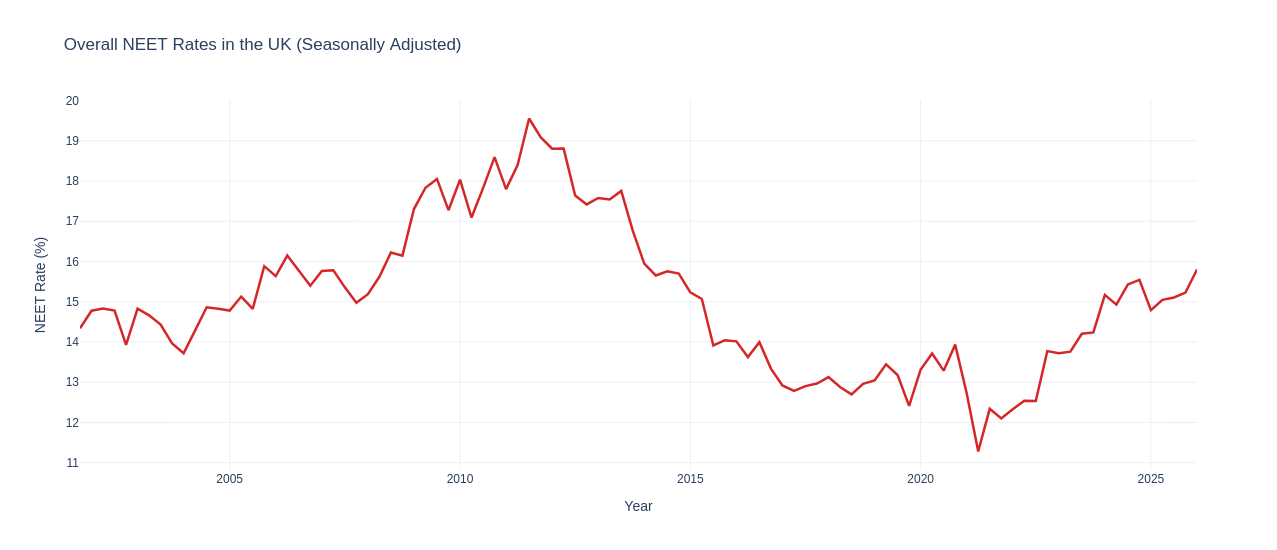

In [6]:
col_neet_1824 = find_col(df_neet_people, "18-24", "NEET as a percentage")

fig_neet_overall = go.Figure(data=[
    line_trace(df_neet_people['Year_Fraction'], df_neet_people[col_neet_1824],
               'Aged 18-24 NEET Rate', '#d62728', width=2.5)
])
style_figure(fig_neet_overall, 'Overall NEET Rates in the UK (Seasonally Adjusted)', 'NEET Rate (%)')
fig_neet_overall.show()

And the same NEET rate split out by gender.

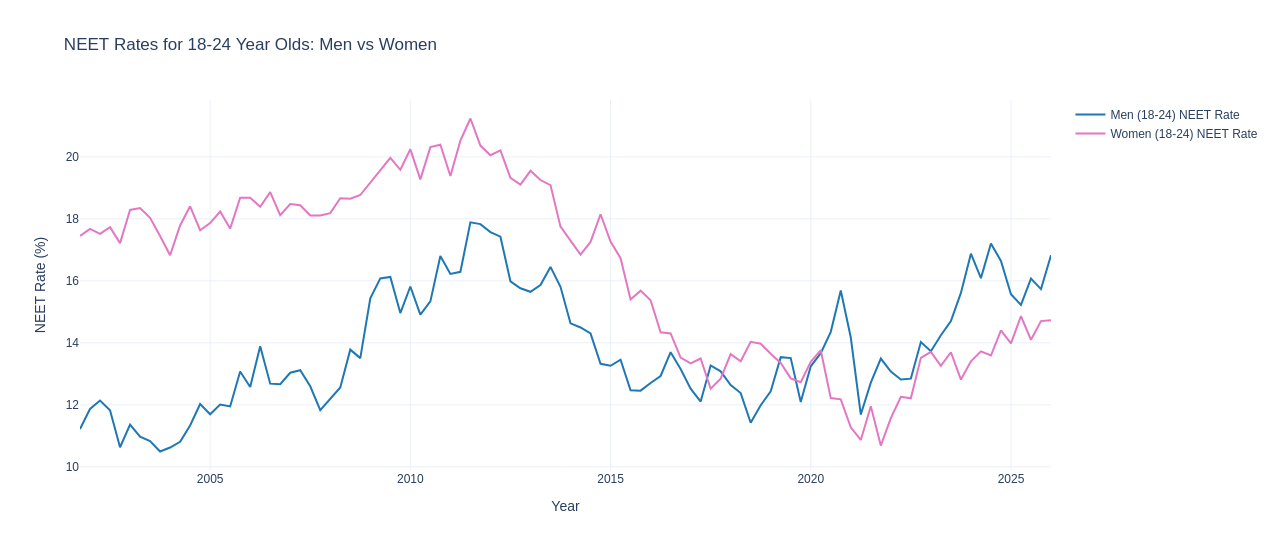

In [7]:
fig_neet_gender = go.Figure(data=[
    line_trace(df_neet_men['Year_Fraction'], df_neet_men[col_neet_1824], 'Men (18-24) NEET Rate', '#1f77b4'),
    line_trace(df_neet_women['Year_Fraction'], df_neet_women[col_neet_1824], 'Women (18-24) NEET Rate', '#e377c2'),
])
style_figure(fig_neet_gender, 'NEET Rates for 18-24 Year Olds: Men vs Women', 'NEET Rate (%)')
fig_neet_gender.show()

I think the NEET rate going down for young women during the 2010s is really interesting. It could be the result of female inclusion in education, lower rates of young parernthood allowing people to enter the workforce, post-financial crisis work necessity. Unsure.

Clearly NEET rates have risen post-COVID, during a Cost-of-Living Crisis, paired with a difficult job search market.

I should compare employment rates / new employees taken on by skilled vs unskilled sectors. It might show that this is a skills gap issue, as we see in many in-demand tech roles.

## The "NEET Gap": what if these young people were employed instead?

To make the NEET rate concrete, this chart merges the employment and NEET datasets and models two hypothetical scenarios on top of the actual employment rate: what employment would look like if the NEET rate were **halved**, and what it would look like if it were **eliminated entirely** (i.e. every NEET became employed).

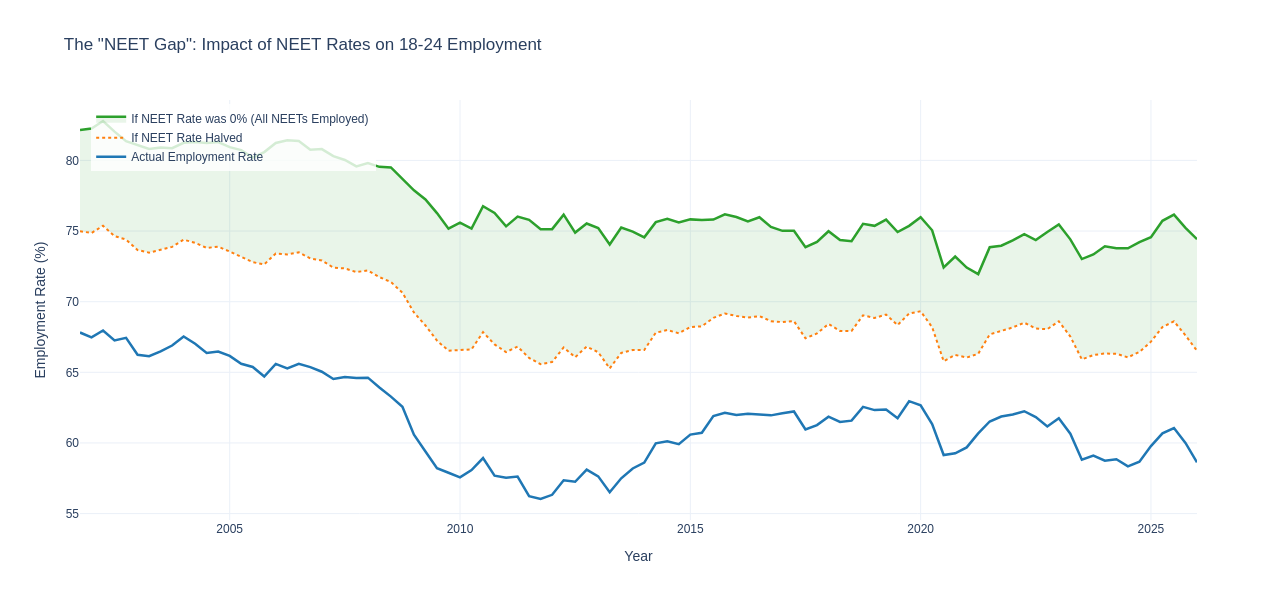

In [8]:
col_emp_1824 = find_col(df_people, "Aged 18-24", "Employment_rate")

df_analysis = pd.merge(df_people, df_neet_people, on="Year_Fraction", suffixes=('_A05', '_NEET'))
df_analysis = df_analysis[['Year_Fraction', 'Period_A05', col_emp_1824, col_neet_1824]].dropna().copy()

df_analysis['Potential_Emp_Half_NEET'] = df_analysis[col_emp_1824] + (df_analysis[col_neet_1824] * 0.5)
df_analysis['Potential_Emp_Zero_NEET'] = df_analysis[col_emp_1824] + df_analysis[col_neet_1824]

fig_scenario = go.Figure(data=[
    line_trace(df_analysis['Year_Fraction'], df_analysis[col_emp_1824],
               'Actual Employment Rate', '#1f77b4', width=2.5),
    line_trace(df_analysis['Year_Fraction'], df_analysis['Potential_Emp_Half_NEET'],
               'If NEET Rate Halved', '#ff7f0e', dash='dot'),
    go.Scatter(
        x=df_analysis['Year_Fraction'], y=df_analysis['Potential_Emp_Zero_NEET'],
        mode='lines', name='If NEET Rate was 0% (All NEETs Employed)',
        line=dict(color='#2ca02c', width=2.5),
        fill='tonexty',  # shades the area down to the previous trace
        fillcolor='rgba(44, 160, 44, 0.1)',
    ),
])
style_figure(
    fig_scenario, 'The "NEET Gap": Impact of NEET Rates on 18-24 Employment', 'Employment Rate (%)',
    height=600, width=900,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255, 255, 255, 0.8)"),
)
fig_scenario.show()

## Long-run inactivity trend

Zooming out, here's the long-run economic inactivity rate for 18-24 year olds on its own, drawn with Matplotlib and saved to disk for reuse outside the notebook.

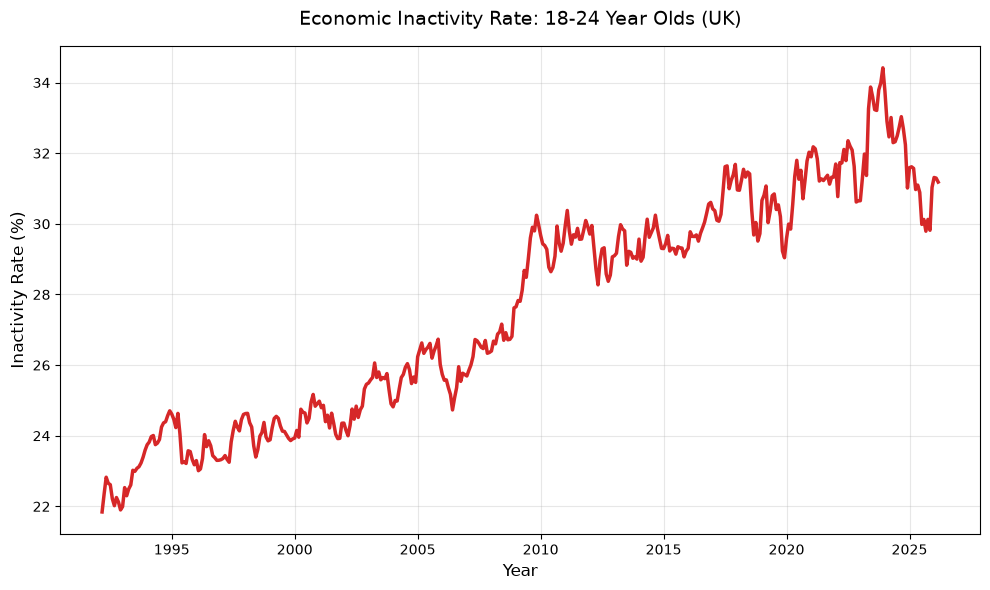

In [9]:
target_col = find_col(df_people, "Aged 18-24", "Inactivity_rate")

plt.figure(figsize=(10, 6))
plt.plot(df_people['Year_Fraction'], df_people[target_col], color='#d62728', linewidth=2.5)
plt.title('Economic Inactivity Rate: 18-24 Year Olds (UK)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inactivity Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('inactivity_1824.png')
plt.show()

## Where do 18-24 year olds stand today?

Finally, a snapshot pie chart breaking the most recent quarter's 18-24 population down into: employed, in full-time education (economically inactive but not NEET), NEET-and-inactive, and NEET-and-unemployed.

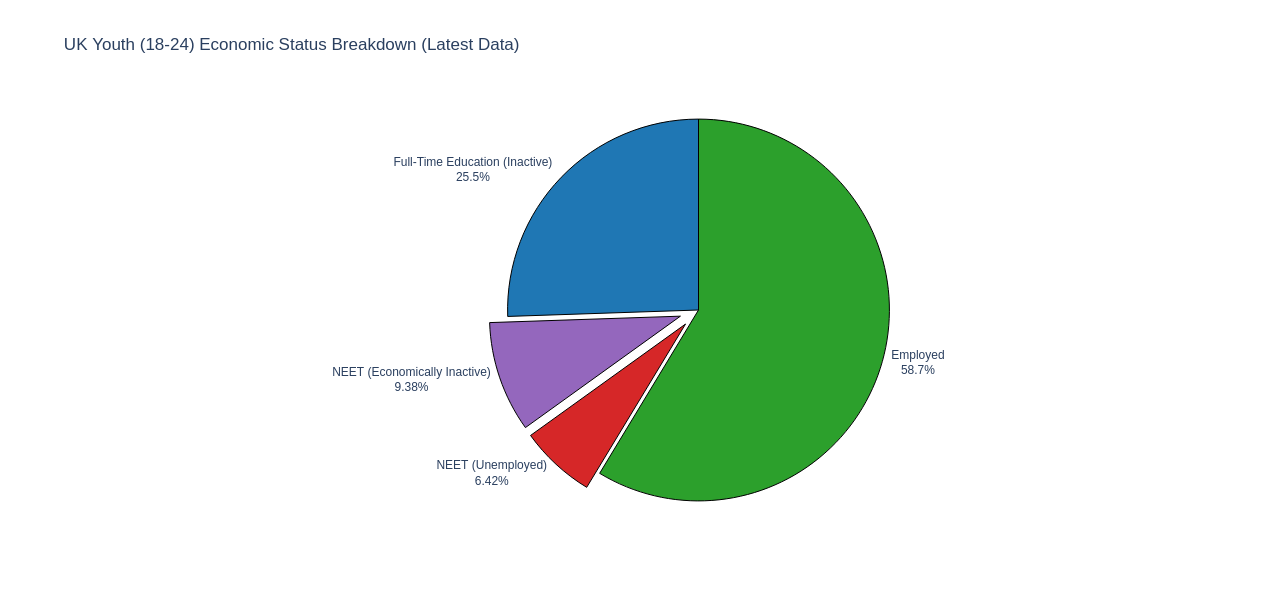

In [10]:
latest_emp = df_people.iloc[-1][col_emp_1824]

pop_col = find_col(df_neet_people, "18-24", "Total people in relevant population group")
unemp_col = find_col(df_neet_people, "18-24", "Unemployed")
inact_col = find_col(df_neet_people, "18-24", "Economically inactive")

df_neet_people['Unemployed_NEET_Rate'] = (df_neet_people[unemp_col] / df_neet_people[pop_col]) * 100
df_neet_people['Inactive_NEET_Rate'] = (df_neet_people[inact_col] / df_neet_people[pop_col]) * 100

latest_neet = df_neet_people.iloc[-1]
unemp_neet = latest_neet['Unemployed_NEET_Rate']
inact_neet = latest_neet['Inactive_NEET_Rate']

# The remaining share is assumed to be in full-time education (inactive, non-NEET)
inact_students = 100 - latest_emp - (unemp_neet + inact_neet)

labels = ['Employed', 'Full-Time Education (Inactive)', 'NEET (Economically Inactive)', 'NEET (Unemployed)']
values = [latest_emp, inact_students, inact_neet, unemp_neet]
colors = ['#2ca02c', '#1f77b4', '#9467bd', '#d62728']

fig_pie = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    pull=[0, 0, 0.1, 0.1],  # explode the NEET slices slightly for emphasis
    marker=dict(colors=colors, line=dict(color='#000000', width=1)),
    textinfo='percent+label',
    textposition='outside',
)])

fig_pie.update_layout(
    title_text='UK Youth (18-24) Economic Status Breakdown (Latest Data)',
    height=600,
    showlegend=False,
)
fig_pie.show()